**Cell 1: Import Library yang Dibutuhkan**

In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Cell 2: Membaca Dataset**

In [12]:
df_nps = pd.read_csv('nps_surveys_with_feedback.csv')
df_account = pd.read_csv('customer_accounts.csv')
df_billing = pd.read_csv('billing_data.csv')
df_support = pd.read_csv('support_tickets.csv')
df_usage = pd.read_csv('monthly_usage_metrics.csv')

print("Data berhasil dimuat. Mulai menggabungkan...")

# --- MENCEGAH ERROR KOLOM KEMBAR (SOLUSI KEYERROR) ---
# Karena plan_type & contract_type sudah ada di df_nps, kita buang dari df_account sebelum digabung
if 'plan_type' in df_account.columns:
    df_account = df_account.drop(columns=['plan_type', 'contract_type'])

# 2. Menggabungkan file satu per satu menggunakan 'customer_id'
# Gabung NPS dengan Data Akun
df_master = pd.merge(df_nps, df_account, on='customer_id', how='left')

# Gabung dengan Data Penggunaan Bulanan
df_master = pd.merge(df_master, df_usage, on='customer_id', how='left')

# Agregasi & Gabung dengan Data Tagihan (Rata-rata jumlah tagihan per pelanggan)
if 'payment_value' in df_billing.columns:
    billing_summary = df_billing.groupby('customer_id')['payment_value'].mean().reset_index()
    billing_summary.rename(columns={'payment_value': 'avg_payment_value'}, inplace=True)
    df_master = pd.merge(df_master, billing_summary, on='customer_id', how='left')

# Agregasi & Gabung dengan Data Tiket Bantuan (Total komplain per pelanggan)
support_count = df_support.groupby('customer_id')['ticket_id'].count().reset_index()
support_count.rename(columns={'ticket_id': 'total_complaints'}, inplace=True)
df_master = pd.merge(df_master, support_count, on='customer_id', how='left')

# 3. Mengisi data yang kosong (NaN) dengan angka 0
df_master['total_complaints'] = df_master['total_complaints'].fillna(0)
if 'avg_payment_value' in df_master.columns:
    df_master['avg_payment_value'] = df_master['avg_payment_value'].fillna(0)

# 4. Pembersihan Awal
df_master = df_master.dropna(subset=['segment', 'feedback_text'])

# 5. KUNCI PENTING: Kembalikan nama variabel menjadi 'df' agar Cell 3 ke bawah tidak error
df = df_master

print(f"Total data siap pakai setelah digabung: {df.shape[0]} baris.")
print("Daftar Kolom Aman:", df.columns.tolist())
display(df.head())

Data berhasil dimuat. Mulai menggabungkan...
Total data siap pakai setelah digabung: 4549 baris.
Daftar Kolom Aman: ['survey_id', 'customer_id', 'nps_score', 'survey_date', 'plan_type', 'contract_type', 'segment', 'feedback_category', 'feedback_text', 'subscription_date', 'total_users', 'unsubscribed_date', 'monthly_usage_hrs', 'feature_adoption_pct', 'last_login_date', 'avg_payment_value', 'total_complaints']


,survey_id,customer_id,nps_score,survey_date,plan_type,contract_type,segment,feedback_category,feedback_text,subscription_date,total_users,unsubscribed_date,monthly_usage_hrs,feature_adoption_pct,last_login_date,avg_payment_value,total_complaints
0,SV-01430,C-0001,2.0,2024-12-02,Starter,Monthly,detractor,Account,Honestly this platform has been a total nightm...,2023-05-31,4.0,2024-12-05,20.1,73.6,2024-11-27,112.58,0.0
1,SV-01431,C-0001,2.0,2024-04-27,Starter,Monthly,detractor,Account,After months of dealing with constant call dro...,2023-05-31,4.0,2024-12-05,20.1,73.6,2024-11-27,112.58,0.0
2,SV-01928,C-0002,2.0,2024-04-01,Starter,Annual,detractor,Billing,Billing errors kept piling up and the invoices...,2023-10-31,1.0,2024-11-02,25.6,54.8,2024-10-25,1074.24,17.0
3,SV-01927,C-0002,1.0,2024-12-17,Starter,Annual,detractor,Billing,We’ve been battling unresolved billing dispute...,2023-10-31,1.0,2024-11-02,25.6,54.8,2024-10-25,1074.24,17.0
4,SV_C-0003_1,C-0003,9.0,2024-10-24,Professional,Annual,promoter,Feature Request,Our team loves the call routing and video qual...,2023-01-31,9.0,NaN,136.1,66.0,2024-11-25,9575.52,3.0


**Cell 3: Pemisahan & Encoding Target**

In [13]:
# [TAMBAHAN] Hapus baris yang kolom 'segment'-nya kosong (NaN)
df_model = df.dropna(subset=['segment'])

# Hapus kolom yang tidak dipakai
df_model = df_model.drop(columns=['survey_id', 'customer_id', 'survey_date', 'nps_score'])

# Pisahkan Fitur (X) dan Target (y)
X_cat = df_model[['plan_type', 'contract_type', 'feedback_category']]
X_text = df_model['feedback_text']
y = df_model['segment']

# Ubah Target ke Angka
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

target_names = label_encoder.classes_
print("Mapping Kelas:", dict(zip(target_names, range(len(target_names)))))

Mapping Kelas: {'detractor': 0, 'passive': 1, 'promoter': 2}


**Cell 4: Feature Engineering (TF-IDF & One-Hot)**

In [14]:
# 1. Encoding Kategori
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_encoded = ohe.fit_transform(X_cat)

# 2. Encoding Teks (TF-IDF)
# Ubah baris TF-IDF sebelumnya menjadi seperti ini:
tfidf = TfidfVectorizer(max_features=1500, stop_words='english', ngram_range=(1, 2))

# [INI BARIS YANG HILANG] Kita harus memasukkan X_text agar diubah menjadi angka
X_text_encoded = tfidf.fit_transform(X_text).toarray()

# 3. Gabungkan
X_final = np.hstack((X_cat_encoded, X_text_encoded))

# --- OUTPUT YANG LEBIH BAGUS ---
print("📊 === HASIL FEATURE ENGINEERING ===")
print(f"🔸 Fitur Kategori (One-Hot) : Diterjemahkan menjadi {X_cat_encoded.shape[1]} kolom.")
print(f"🔸 Fitur Teks (TF-IDF)      : Mengekstrak {X_text_encoded.shape[1]} kata terpenting menjadi kolom.")
print("-" * 40)
print(f"✅ Total Fitur Gabungan (X) : {X_final.shape[1]} petunjuk yang akan dipelajari AI.")
print(f"✅ Total Baris Data         : {X_final.shape[0]} pelanggan.")
print("==================================\n")

📊 === HASIL FEATURE ENGINEERING ===
🔸 Fitur Kategori (One-Hot) : Diterjemahkan menjadi 14 kolom.
🔸 Fitur Teks (TF-IDF)      : Mengekstrak 1500 kata terpenting menjadi kolom.
----------------------------------------
✅ Total Fitur Gabungan (X) : 1514 petunjuk yang akan dipelajari AI.
✅ Total Baris Data         : 4549 pelanggan.



**Cell 5: Train-Test Split (Data Latihan vs Data Ujian)**

In [15]:
# Membagi data dengan porsi 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- OUTPUT YANG LEBIH BAGUS ---
print("✂️ === PEMBAGIAN DATA (TRAIN-TEST SPLIT) ===")
print(f"Total Keseluruhan Dataset : {X_final.shape[0]} pelanggan")
print("-" * 45)
print(f"🎓 Data Pelatihan (80%)   : {X_train.shape[0]} pelanggan (Digunakan untuk melatih AI)")
print(f"🎯 Data Pengujian (20%)   : {X_test.shape[0]} pelanggan (Disembunyikan untuk menguji akurasi)")
print("============================================\n")

✂️ === PEMBAGIAN DATA (TRAIN-TEST SPLIT) ===
Total Keseluruhan Dataset : 4549 pelanggan
---------------------------------------------
🎓 Data Pelatihan (80%)   : 3639 pelanggan (Digunakan untuk melatih AI)
🎯 Data Pengujian (20%)   : 910 pelanggan (Disembunyikan untuk menguji akurasi)



**Cell 6: Menghitung Class Weights**

In [16]:
# Menghitung bobot untuk mengatasi data yang tidak seimbang
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# --- OUTPUT YANG LEBIH BAGUS ---
print("⚖️ === PEMBOBOTAN KELAS (ANTI-IMBALANCE) ===")
print("Tujuan: Memberikan 'hukuman' lebih besar agar AI tidak mengabaikan kelas minoritas.\n")

for class_idx, weight in class_weight_dict.items():
    # Mengambil nama kelas asli dari Label Encoder di Cell 3
    class_name = target_names[class_idx]

    # Mencetak dengan format yang rapi
    print(f"➔ Kelas '{class_name.upper()}'")
    print(f"   Bobot penalti: {weight:.2f}")
print("============================================\n")

⚖️ === PEMBOBOTAN KELAS (ANTI-IMBALANCE) ===
Tujuan: Memberikan 'hukuman' lebih besar agar AI tidak mengabaikan kelas minoritas.

➔ Kelas 'DETRACTOR'
   Bobot penalti: 0.51
➔ Kelas 'PASSIVE'
   Bobot penalti: 1.40
➔ Kelas 'PROMOTER'
   Bobot penalti: 3.20



**Cell 7:Memanipulasi Data dengan SMOTE (Synthetic Minority Over-sampling Technique)**

In [17]:
from imblearn.over_sampling import SMOTE

print("Menggunakan SMOTE untuk menyeimbangkan data...")
smote = SMOTE(random_state=42)

# X_train dan y_train yang aslinya timpang, kita ratakan!
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Jumlah data latihan SEBELUM SMOTE: {X_train.shape[0]}")
print(f"Jumlah data latihan SESUDAH SMOTE: {X_train_smote.shape[0]}")

Menggunakan SMOTE untuk menyeimbangkan data...
Jumlah data latihan SEBELUM SMOTE: 3639
Jumlah data latihan SESUDAH SMOTE: 7188


**Cell 8: Arsitektur MLP Anti-Overfitting (V2)**

In [18]:
from tensorflow.keras.regularizers import l2

# Membangun Arsitektur Model
model = tf.keras.Sequential([
    # Hidden Layer 1: Menangkap pola dasar
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.4),

    # Hidden Layer 2: Mencari pola yang lebih abstrak
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    tf.keras.layers.Dropout(0.4),

    # Hidden Layer 3: Penyaringan fitur akhir
    tf.keras.layers.Dense(32, activation='relu'),

    # Output Layer: 3 Keputusan akhir (Detractor, Passive, Promoter)
    tf.keras.layers.Dense(3, activation='softmax')
])

# Mengkompilasi Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# --- OUTPUT YANG LEBIH BAGUS ---
print("🧠 === ARSITEKTUR DEEP LEARNING (MLP V2) ===")
print("Telah dirancang dengan fitur Anti-Overfitting (L2 & Dropout 40%):")
print("🔸 Hidden Layer 1 : 128 Neuron (Pengekstraksi Pola Awal)")
print("🔸 Hidden Layer 2 : 64 Neuron  (Pengekstraksi Pola Lanjut)")
print("🔸 Hidden Layer 3 : 32 Neuron  (Penyaringan Fitur Akhir)")
print("🔸 Output Layer   : 3 Neuron   (Aktivasi Softmax untuk Probabilitas Kelas)")
print("-" * 55)
print("✅ Status Kompilasi : Berhasil menggunakan Optimizer 'Adam'")
print("=======================================================\n")

# Menampilkan tabel ringkasan teknis bawaan dari TensorFlow/Keras
print("Rincian Parameter (Bobot yang akan dilatih AI):")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


🧠 === ARSITEKTUR DEEP LEARNING (MLP V2) ===
Telah dirancang dengan fitur Anti-Overfitting (L2 & Dropout 40%):
🔸 Hidden Layer 1 : 128 Neuron (Pengekstraksi Pola Awal)
🔸 Hidden Layer 2 : 64 Neuron  (Pengekstraksi Pola Lanjut)
🔸 Hidden Layer 3 : 32 Neuron  (Penyaringan Fitur Akhir)
🔸 Output Layer   : 3 Neuron   (Aktivasi Softmax untuk Probabilitas Kelas)
-------------------------------------------------------
✅ Status Kompilasi : Berhasil menggunakan Optimizer 'Adam'

Rincian Parameter (Bobot yang akan dilatih AI):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       193,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,355 (798.26 KB)

 Trainable params: 204,355 (798.26 KB)

 Non-trainable params: 0 (0.00 B)

**Cell 9: Memasang Early Stopping & Melatih Model**

In [19]:
# [BARU] Early Stopping
# Jika Validation Loss tidak turun selama 3 Epoch berturut-turut, hentikan!
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True # Kembalikan model ke kondisi terbaiknya sebelum overfitting
)

print("Memulai pelatihan dengan pengaman Early Stopping & Class Weights...\n")

history = model.fit(
    X_train, y_train,
    epochs=20, # Kita set 20, tapi akan berhenti otomatis sebelum 20 jika overfitting
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict, # Masukkan bobot hukuman
    callbacks=[early_stop] # Masukkan pengaman
)

Memulai pelatihan dengan pengaman Early Stopping & Class Weights...

Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6994 - loss: 1.0290 - val_accuracy: 0.8165 - val_loss: 0.6925
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8590 - loss: 0.6421 - val_accuracy: 0.8593 - val_loss: 0.6078
Epoch 3/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8876 - loss: 0.5439 - val_accuracy: 0.8802 - val_loss: 0.5634
Epoch 4/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8983 - loss: 0.4854 - val_accuracy: 0.8758 - val_loss: 0.5689
Epoch 5/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9137 - loss: 0.4249 - val_accuracy: 0.8626 - val_loss: 0.6246
Epoch 6/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9217 - loss: 0.3817 - val_accuracy: 0.8615 - val_loss: 0.6337


**Cell 10: Evaluasi Tingkat Lanjut (Matriks Konfusi & Grafik)**

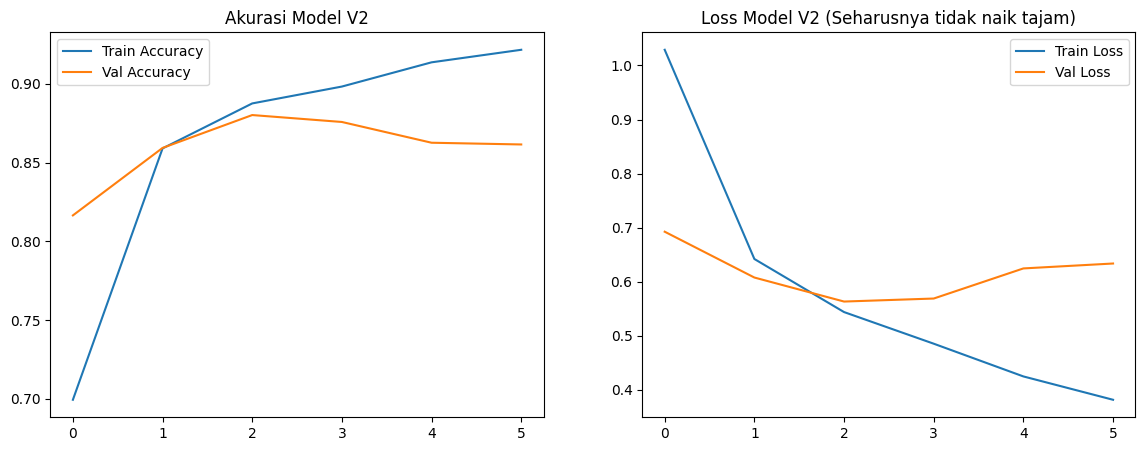

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

📝 LAPORAN KLASIFIKASI LENGKAP
              precision    recall  f1-score   support

   detractor       0.95      0.90      0.93       599
     passive       0.75      0.85      0.80       216
    promoter       0.78      0.79      0.79        95

    accuracy                           0.88       910
   macro avg       0.83      0.85      0.84       910
weighted avg       0.89      0.88      0.88       910



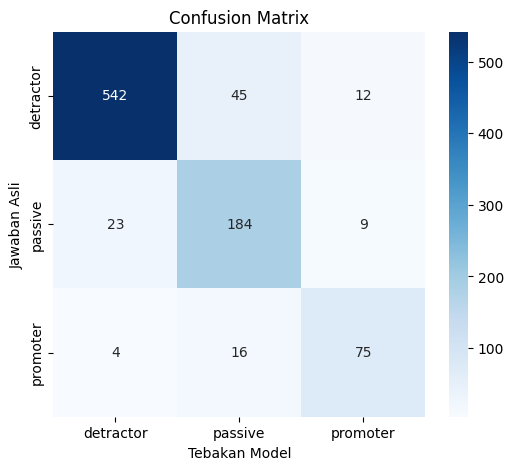

In [20]:
# 1. Plot Grafik Performa
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Akurasi Model V2')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Loss Model V2 (Seharusnya tidak naik tajam)')
ax[1].legend()
plt.show()

# 2. Confusion Matrix & Classification Report
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\n" + "="*50)
print("📝 LAPORAN KLASIFIKASI LENGKAP")
print("="*50)
print(classification_report(y_test, y_pred, target_names=target_names))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Tebakan Model')
plt.ylabel('Jawaban Asli')
plt.show()

**Cell 11: ROC dan AUC**

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


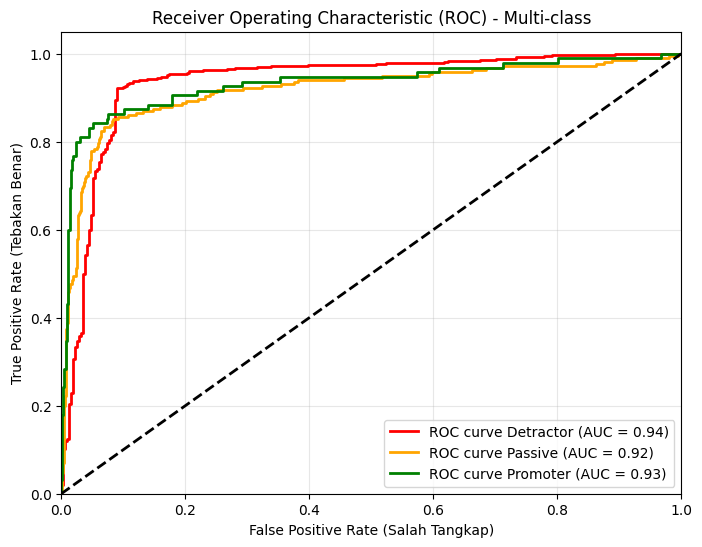

 📊 LAPORAN EVALUASI MODEL DEEP LEARNING (MLP)
✅ OVERALL ACCURACY: 88.02%
Artinya, model berhasil menebak segmen dengan benar pada 88 dari 100 pelanggan.

👉 DETAIL PER KELAS (Precision & Recall):
🔹 Detractor: Precision 0.95 | Recall 0.90 | AUC 0.94
🔹 Passive  : Precision 0.75 | Recall 0.85 | AUC 0.92
🔹 Promoter : Precision 0.78 | Recall 0.79 | AUC 0.93

👉 INTERPRETASI AUC:
🔴 Detractor : Peluang 94% mendeteksi risiko churn dengan tepat.
🟢 Promoter  : Peluang 93% mengenali pelanggan setia dengan akurat.
🟠 Passive   : Peluang 92% membedakan pelanggan netral.

💡 ANALISIS SINGKAT:
Model memiliki performa yang LUAR BIASA (Excellent). Akurasi dan AUC yang
tinggi menunjukkan model sangat stabil dalam memproses data baru.


In [21]:
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Persiapan Data & Prediksi
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = model.predict(X_test) # Probabilitas untuk ROC/AUC
y_pred = np.argmax(y_score, axis=1) # Kelas pasti untuk Accuracy/Precision
n_classes = y_test_bin.shape[1]

# 2. Hitung Metrik Utama (Accuracy, Precision, Recall, F1)
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

# 3. Hitung ROC dan AUC untuk setiap kelas
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot Grafik ROC
plt.figure(figsize=(8, 6))
colors = ['red', 'orange', 'green']
labels = ['Detractor', 'Passive', 'Promoter']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve {labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Salah Tangkap)')
plt.ylabel('True Positive Rate (Tebakan Benar)')
plt.title('Receiver Operating Characteristic (ROC) - Multi-class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 5. Cetak Penjelasan Lengkap (Ringkasan Eksekutif)
print("="*65)
print(" 📊 LAPORAN EVALUASI MODEL DEEP LEARNING (MLP)")
print("="*65)
print(f"✅ OVERALL ACCURACY: {acc*100:.2f}%")
print("Artinya, model berhasil menebak segmen dengan benar pada {0:.0f} dari 100 pelanggan.\n".format(acc*100))

print("👉 DETAIL PER KELAS (Precision & Recall):")
for i, label in enumerate(labels):
    print(f"🔹 {label:9}: Precision {prec[i]:.2f} | Recall {rec[i]:.2f} | AUC {roc_auc[i]:.2f}")

print("\n👉 INTERPRETASI AUC:")
print(f"🔴 Detractor : Peluang {roc_auc[0]*100:.0f}% mendeteksi risiko churn dengan tepat.")
print(f"🟢 Promoter  : Peluang {roc_auc[2]*100:.0f}% mengenali pelanggan setia dengan akurat.")
print(f"🟠 Passive   : Peluang {roc_auc[1]*100:.0f}% membedakan pelanggan netral.\n")

print("💡 ANALISIS SINGKAT:")
if acc > 0.85:
    print("Model memiliki performa yang LUAR BIASA (Excellent). Akurasi dan AUC yang")
    print("tinggi menunjukkan model sangat stabil dalam memproses data baru.")
else:
    print("Model memiliki performa yang baik, namun masih ada ruang untuk optimasi")
    print("pada fitur teks atau penyeimbangan data.")
print("="*65)

**Cell 12: Export Model & Preprocessing Tools**

In [22]:
import pickle

print("💾 === PROSES EXPORT MODEL & ENCODER ===")

# 1. Menyimpan Model Deep Learning (Format H5)
model.save('mlp_churn_model.h5')
print("✅ Model MLP berhasil disimpan sebagai 'mlp_churn_model.h5'")

# 2. Menyimpan Alat Preprocessing (Format Pickle)
# Kita simpan TF-IDF, OneHotEncoder, dan LabelEncoder agar di backend nanti
# data baru bisa diterjemahkan dengan standar yang sama persis.
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)
print("✅ TF-IDF Vectorizer berhasil disimpan sebagai 'tfidf_vectorizer.pkl'")

with open('onehot_encoder.pkl', 'wb') as file:
    pickle.dump(ohe, file)
print("✅ One-Hot Encoder berhasil disimpan sebagai 'onehot_encoder.pkl'")

with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)
print("✅ Label Encoder berhasil disimpan sebagai 'label_encoder.pkl'")

print("-" * 45)
print("🎉 TUGAS DEEP LEARNING SELESAI! 🎉")
print("Silakan unduh keempat file di atas dari panel folder Colab (sebelah kiri)")
print("========================================")

💾 === PROSES EXPORT MODEL & ENCODER ===
✅ Model MLP berhasil disimpan sebagai 'mlp_churn_model.h5'
✅ TF-IDF Vectorizer berhasil disimpan sebagai 'tfidf_vectorizer.pkl'
✅ One-Hot Encoder berhasil disimpan sebagai 'onehot_encoder.pkl'
✅ Label Encoder berhasil disimpan sebagai 'label_encoder.pkl'
---------------------------------------------
🎉 TUGAS DEEP LEARNING SELESAI! 🎉
Silakan unduh keempat file di atas dari panel folder Colab (sebelah kiri)
